<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [70]:
#Importation de la librairie Pandas
import pandas as pd

In [71]:
#Importation de la librairie plotly express
import plotly.express as px

In [72]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [73]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel('erp.xlsx')
#importation du fichier liaison.xlsx
df_liaison = pd.read_excel('liaison.xlsx')

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [74]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [75]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", len(df_erp.columns))

#La nature des données dans chacune des colonnes
print("\nNature des données dans chaque colonne :\n", df_erp.dtypes)

#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs présentes dans chaque colonne :\n", df_erp.count())


Nombre de colonnes : 6

Nature des données dans chaque colonne :
 product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object

Nombre de valeurs présentes dans chaque colonne :
 product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64


In [76]:
#Afficher les 5 premières lignes de la table
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [77]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
df_erp.duplicated(subset="product_id").sum()

0

In [78]:
#Afficher les valeurs distinctes de la colonne stock_status
df_erp["stock_status"].unique()

#À quelle(s) autre(s) colonne(s) sont-elles liées ?


array(['instock', 'outofstock'], dtype=object)

In [79]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if x == 0 else 'instock')
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [80]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [81]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#df_erp["stock_status"] == df_erp["stock_status_2"]).value_counts()
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
df_erp['stock_status'] = df_erp['stock_status_2']
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,instock,23.77,instock


In [82]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [83]:
#Corriger la ou les données incohérentes
df_web[(df_web['post_type'] == 'product') & (df_web['sku'].isnull())]
#Verification en utilisant le même code que plus haut pour afficher les problemes

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,NaN,0,0,0,0.0,-56.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,NaN,0,0,0,0.0,-17.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [84]:
rows_to_update = df_web[(df_web['post_type'] == 'product') & (df_web['sku'].isnull())]

for index, row in rows_to_update.iterrows():
  new_sku = "NEW_SKU_" + str(index)
  df_web.loc[index, 'sku'] = new_sku

df_web[(df_web['post_type'] == 'product') & (df_web['sku'].isnull())]

df_web.iloc[[1084, 1087]]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,...,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,NEW_SKU_1084,0,0,0,0.0,-56.0,taxable,NaN,2.0,2018-08-08 11:23:43,...,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,NEW_SKU_1087,0,0,0,0.0,-17.0,taxable,NaN,2.0,2018-07-31 12:07:23,...,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [85]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?

#Afficher le ou les prix non renseignés dans la colonne "price"
#print("Nombres d'article avec un prix non renseignés: {}".format())

#Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"

#Afficher le prix maximum de la colonne "price"

#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)

print("Nombres d'article avec un prix non renseignés: {}".format(df_erp['price'].isnull().sum()))
print("Prix minimum: {}".format(df_erp['price'].min()))
print("Prix maximum: {}".format(df_erp['price'].max()))
print("Nombre de prix inférieur à 0: {}".format(len(df_erp[df_erp['price'] < 0])))
print("Nombre de prix égal à 0: {}".format(len(df_erp[df_erp['price'] == 0])))

#SC #Dans les colonnes PRICE et STOCK_QUANTITY, retire les signes "-" car erreur de saisie
df_erp['price'] = df_erp['price'].apply(lambda x: abs(x) if isinstance(x, (int, float)) and x < 0 else x)

Nombres d'article avec un prix non renseignés: 0
Prix minimum: -20.0
Prix maximum: 225.0
Nombre de prix inférieur à 0: 3
Nombre de prix égal à 0: 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [86]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"

#Afficher la quantité maximum de la colonne "stock_quantity"

#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)

print("Quantité minimum de stock: {}".format(df_erp['stock_quantity'].min()))
print("Quantité maximum de stock: {}".format(df_erp['stock_quantity'].max()))
print("Stocks inférieurs à 0:\n{}".format(df_erp[df_erp['stock_quantity'] < 0]))

#SC #Dans la colonne STOCK_QUANTITY, retire les signes "-" car erreur de saisie
df_erp['stock_quantity'] = df_erp['stock_quantity'].apply(lambda x: abs(x) if isinstance(x, (int, float)) and x < 0 else x)

Quantité minimum de stock: -10
Quantité maximum de stock: 145
Stocks inférieurs à 0:
     product_id  onsale_web  price  stock_quantity stock_status  \
449        4973           0   10.0             -10      instock   
573        5700           1   44.5              -1      instock   

     purchase_price stock_status_2  
449            4.96        instock  
573           22.30        instock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [87]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
df_erp["onsale_web"].unique()
print(df_erp["onsale_web"].value_counts())
#1 = en ligne // 0 = hors ligne

onsale_web
1    716
0    109
Name: count, dtype: int64


In [88]:
#Quelles sont les colonnes à conserver selon vous?
print(df_erp.columns)

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price', 'stock_status_2'],
      dtype='object')


In [89]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
df_erp = df_erp.drop('stock_status_2', axis=1)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [90]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombres d'article avec un prix d'achat non renseignés: {}".format(df_erp['purchase_price'].isnull().sum()))

#Afficher le prix minimum de la colonne "purchase_price"
print("Prix d'achat minimum: {}".format(df_erp['purchase_price'].min()))

#Afficher le prix maximum de la colonne "purchase_price"
print("Prix d'achat maximum: {}".format(df_erp['purchase_price'].max()))

Nombres d'article avec un prix d'achat non renseignés: 0
Prix d'achat minimum: 2.74
Prix d'achat maximum: 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [91]:
#Dimension du dataset
#Nombre d'observations

#Nombre de caractéristiques
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))


Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [92]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", len(df_web.columns))

#La nature des données dans chacune des colonnes
print("\nNature des données dans chaque colonne :\n", df_web.dtypes)

#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs présentes dans chaque colonne :\n", df_web.count())

Nombre de colonnes : 29

Nature des données dans chaque colonne :
 sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64
post_parent  

In [93]:
#Selon vous, quelles sont les colonnes à conserver ?
#Toute les colonnes qui contiennent de la data

In [94]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web.dropna(axis=1, how='all')
print("\nNombre de valeurs présentes dans chaque colonne :\n", df_web.count())


Nombre de valeurs présentes dans chaque colonne :
 sku                  1430
virtual              1513
downloadable         1513
rating_count         1513
average_rating       1430
total_sales          1430
tax_status            716
post_author          1430
post_date            1430
post_date_gmt        1430
product_type         1429
post_title           1430
post_excerpt          716
post_status          1430
comment_status       1430
ping_status          1430
post_name            1430
post_modified        1430
post_modified_gmt    1430
post_parent          1430
guid                 1430
menu_order           1430
post_type            1430
post_mime_type        714
comment_count        1430
dtype: int64


In [95]:
#Visualisation des valeurs de la colonne sku
print(df_web['sku'].unique())
print()
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
import re

def is_valid_sku(sku):
  """Checks if a SKU follows the expected format (alphanumeric characters only)."""
  return bool(re.fullmatch(r'^[a-zA-Z0-9]+$', str(sku)))

invalid_skus = [sku for sku in df_web['sku'].unique() if not is_valid_sku(sku)]
print("Invalid SKUs:", invalid_skus)

[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

In [96]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?
invalid_skus

['13127-1', 'bon-cadeau-25-euros', 'NEW_SKU_1084', 'NEW_SKU_1087']

In [97]:
#Identifier les lignes sans code articles
df_web[df_web['sku'].isnull()]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,...,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
df_web = df_web.dropna(subset=['sku'])
print("\nNombre de valeurs présentes dans chaque colonne :\n", df_web.count())


Nombre de valeurs présentes dans chaque colonne :
 sku                  1430
virtual              1430
downloadable         1430
rating_count         1430
average_rating       1430
total_sales          1430
tax_status            716
post_author          1430
post_date            1430
post_date_gmt        1430
product_type         1429
post_title           1430
post_excerpt          716
post_status          1430
comment_status       1430
ping_status          1430
post_name            1430
post_modified        1430
post_modified_gmt    1430
post_parent          1430
guid                 1430
menu_order           1430
post_type            1430
post_mime_type        714
comment_count        1430
dtype: int64


In [99]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
print("Nombre de doublons de SKU:", df_web.duplicated(subset=['sku']).sum())
print()

Nombre de doublons de SKU: 714



In [100]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_no_sku = df_web[df_web['sku'].isnull()]
#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
df_web_no_sku.info()
#3 - Que constatez-vous?
#qu'il y a aucune data


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            0 non-null      int64         
 2   downloadable       0 non-null      int64         
 3   rating_count       0 non-null      int64         
 4   average_rating     0 non-null      float64       
 5   total_sales        0 non-null      float64       
 6   tax_status         0 non-null      object        
 7   post_author        0 non-null      float64       
 8   post_date          0 non-null      datetime64[ns]
 9   post_date_gmt      0 non-null      datetime64[ns]
 10  product_type       0 non-null      object        
 11  post_title         0 non-null      object        
 12  post_excerpt       0 non-null      object        
 13  post_status        0 non-null      object        
 14  comment_status     0 non-nu

In [101]:
#SC #suppression du POST_TYPE = 'attachment'
df_web = df_web[df_web.post_type != 'attachment']
print(len(df_web))

716


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [102]:
#Dimension du dataset
#Nombre d'observations

#Nombre de caractéristiques
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [103]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", len(df_liaison.columns))

#La nature des données dans chacune des colonnes
print("\nNature des données dans chaque colonne :\n", df_liaison.dtypes)

#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs présentes dans chaque colonne :\n", df_liaison.count())

Nombre de colonnes : 2

Nature des données dans chaque colonne :
 id_web        object
product_id     int64
dtype: object

Nombre de valeurs présentes dans chaque colonne :
 id_web        734
product_id    825
dtype: int64


In [104]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
print("Nombre de valeurs uniques de product_id dans df_liaison:", df_liaison['product_id'].nunique())
print("Nombre de lignes dans le DataFrame df_liaison:", len(df_liaison))

if df_liaison['product_id'].nunique() == len(df_liaison):
  print("Toutes les valeurs de la colonne 'product_id' sont uniques dans df_liaison.")
else:
  print("Il existe des doublons dans la colonne 'product_id' de df_liaison.")

Nombre de valeurs uniques de product_id dans df_liaison: 825
Nombre de lignes dans le DataFrame df_liaison: 825
Toutes les valeurs de la colonne 'product_id' sont uniques dans df_liaison.


In [105]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print("Nombre de valeurs uniques de id_web dans df_liaison:", df_liaison['id_web'].nunique())
print("Nombre de lignes dans le DataFrame df_liaison:", len(df_liaison))

if df_liaison['id_web'].nunique() == len(df_liaison):
  print("Toutes les valeurs de la colonne 'id_web' sont uniques dans df_liaison.")
else:
  print("Il existe des doublons dans la colonne 'id_web' de df_liaison.")

Nombre de valeurs uniques de id_web dans df_liaison: 734
Nombre de lignes dans le DataFrame df_liaison: 825
Il existe des doublons dans la colonne 'id_web' de df_liaison.


In [106]:
#Avons-nous des articles sans correspondances?
print("Nombre de lignes null dans id_web:", df_liaison['id_web'].isnull().sum())
print("Nombre de lignes null dans product_id:", df_liaison['product_id'].isnull().sum())

Nombre de lignes null dans id_web: 91
Nombre de lignes null dans product_id: 0


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [107]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, on='product_id', how='left')
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1,24.2,16,instock,12.88,15298
1,3849,1,34.3,10,instock,17.54,15296
2,3850,1,20.8,0,outofstock,10.64,15300
3,4032,1,14.1,26,instock,6.92,19814
4,4039,1,46.0,3,instock,23.77,19815


In [108]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?
df_merge_isNULL = df_merge[df_merge['product_id'].isna()]
print("Nombre de ligne ne matchant pas :", df_merge_isNULL.shape[0])

Nombre de ligne ne matchant pas : 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [109]:
#Fusionnez les datasets df_merge et df_web
df_merge = pd.merge(df_merge, df_web, how='left', left_on='id_web', right_on='sku')
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,...,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,3847,1,24.2,16,instock,12.88,15298,15298,0.0,0.0,...,closed,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2019-12-30 08:30:29,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1,3849,1,34.3,10,instock,17.54,15296,15296,0.0,0.0,...,closed,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2019-12-21 08:00:17,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
2,3850,1,20.8,0,outofstock,10.64,15300,15300,0.0,0.0,...,closed,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2020-06-26 16:15:03,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,4032,1,14.1,26,instock,6.92,19814,19814,0.0,0.0,...,closed,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2020-01-04 15:36:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
4,4039,1,46.0,3,instock,23.77,19815,19815,0.0,0.0,...,closed,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2020-01-04 15:36:10,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [110]:
#Avons-nous des lignes sans correspondances?
df_merge_isNULL = df_merge[df_merge['id_web'].isna()]
print("Nombre de ligne ne matchant pas :", df_merge_isNULL.shape[0])

Nombre de ligne ne matchant pas : 91


In [111]:
#Avons-nous des lignes sans correspondances dans df_merge ? reponse : oui
null_sku_rows = df_merge[df_merge['sku'].isna()]
null_sku_rows

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,...,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
19,4055,0,86.1,0,outofstock,37.88,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
49,4090,0,73.0,0,outofstock,33.79,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
50,4092,0,47.0,0,outofstock,25.25,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
119,4195,0,14.1,0,outofstock,7.36,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
131,4209,0,73.5,0,outofstock,33.01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,7200,0,31.0,6,instock,15.54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
819,7201,0,31.0,18,instock,16.02,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
820,7203,0,45.0,30,instock,23.48,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
821,7204,0,45.0,9,instock,24.18,NaN,NaN,NaN,NaN,...,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

In [112]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas
print(df_merge.columns)
px.box(df_merge, y="price", title="Répartition des prix") #product_type
#px.box(df_merge, y="price", x="product_type")

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price', 'id_web', 'sku', 'virtual', 'downloadable',
       'rating_count', 'average_rating', 'total_sales', 'tax_status',
       'post_author', 'post_date', 'post_date_gmt', 'product_type',
       'post_title', 'post_excerpt', 'post_status', 'comment_status',
       'ping_status', 'post_name', 'post_modified', 'post_modified_gmt',
       'post_parent', 'guid', 'menu_order', 'post_type', 'post_mime_type',
       'comment_count'],
      dtype='object')


In [113]:
#Autre méthode avec plotly express
import plotly.express as px
fig = px.box(df_merge, #x="product_type",
             y="price", title="Répartition des prix par type de produit") #par prix
fig.show()









#par prix

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [114]:
#Calculer la moyenne du prix
mean_price = df_merge['price'].mean()
print("Moyenne des prix :", mean_price)
print()

#Calculer l'écart-type du prix
std_price = df_merge['price'].std()
print("Ecart type des prix :", std_price)
print()

#Calculer le Z-score
df_merge['z_score_price'] = (df_merge['price'] - mean_price) / std_price
df_merge[['sku', 'z_score_price']].head()




#

Moyenne des prix : 32.27763636363637

Ecart type des prix : 26.603195978591984



,sku,z_score_price
0,15298,-0.303634
1,15296,0.076020
2,15300,-0.431438
3,19814,-0.683288
4,19815,0.515816


In [115]:
#Quel est le seuil prix dont z-score est supérieur à 3?
threshold_price = df_merge[df_merge['z_score_price'] > 3]['price'].min()
print("Le seuil prix dont le z-score est supérieur à 3 est :", threshold_price)

Le seuil prix dont le z-score est supérieur à 3 est : 114.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [116]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
df_merge['price'].describe()


#info sur la variable prix

,price
count,825.000000
mean,32.277636
std,26.603196
min,5.200000
25%,14.500000
50%,24.300000
75%,42.000000
max,225.000000


In [117]:
#Définissez un seuil pour les articles "outliers" en prix

# Calcul des quartiles Q1 et Q3
Q1 = df_merge['price'].quantile(0.25)
Q3 = df_merge['price'].quantile(0.75)

# Calcul de l'intervalle interquartile (IQR)
IQR = Q3 - Q1

# Définition du seuil supérieur pour les outliers
upper_bound = Q3 + 1.5 * IQR

# Affichage du seuil
print("Seuil supérieur pour les outliers en prix :", upper_bound)

Seuil supérieur pour les outliers en prix : 83.25


In [118]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"

# Nombre d'articles outliers en prix
num_outliers_price = len(df_merge[df_merge['price'] > upper_bound])

# Proportion d'articles outliers en prix par rapport au catalogue total
proportion_outliers_price = num_outliers_price / len(df_merge) * 100

print("Nombre d'articles outliers en prix :", num_outliers_price)
print("Proportion d'articles outliers en prix :", proportion_outliers_price, "%")

Nombre d'articles outliers en prix : 36
Proportion d'articles outliers en prix : 4.363636363636364 %


In [119]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
#outlisers = valeurs abérrantes // oui car produit de luxe

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [120]:
##############################
# Calculer le CA su site web #
##############################

#Créez une colonne calculant le CA par article
df_merge['ca_par_article'] = df_merge['price'] * df_merge['total_sales']
print(df_merge.head())

#Calculez la somme de la colonne "ca_par_article"
#Ce résultat correspond au chiffre d'affaire du site web
ca_total = df_merge['ca_par_article'].sum()
print("Le chiffre d'affaire total du site web est de :", ca_total)

   product_id  onsale_web  price  stock_quantity stock_status  purchase_price  \
0        3847           1   24.2              16      instock           12.88   
1        3849           1   34.3              10      instock           17.54   
2        3850           1   20.8               0   outofstock           10.64   
3        4032           1   14.1              26      instock            6.92   
4        4039           1   46.0               3      instock           23.77   

  id_web    sku  virtual  downloadable  ...       post_modified  \
0  15298  15298      0.0           0.0  ... 2019-12-30 09:30:29   
1  15296  15296      0.0           0.0  ... 2019-12-21 09:00:17   
2  15300  15300      0.0           0.0  ... 2020-06-26 18:15:03   
3  19814  19814      0.0           0.0  ... 2020-01-04 16:36:01   
4  19815  19815      0.0           0.0  ... 2020-01-04 16:36:10   

    post_modified_gmt  post_parent  \
0 2019-12-30 08:30:29          0.0   
1 2019-12-21 08:00:17          0.0

In [121]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge = df_merge.sort_values('ca_par_article', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge = df_merge.reset_index(drop=True)

#Afficher les 20 premier articles en CA
top_20_articles = df_merge[['product_type', 'ca_par_article']].head(20)
print(top_20_articles)

#Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px
fig = px.bar(top_20_articles, y='product_type', x='ca_par_article', title='Top 20 des articles en CA')
fig.show()

   product_type  ca_par_article
0     Champagne          2475.0
1     Champagne          1147.8
2     Champagne          1113.0
3           Vin           824.0
4           Vin           805.0
5     Champagne           781.2
6           Vin           735.0
7           Vin           700.0
8     Champagne           675.0
9     Champagne           672.0
10          Vin           633.6
11       Cognac           628.0
12          Vin           627.0
13    Champagne           616.0
14    Champagne           599.2
15          Vin           594.0
16          Vin           582.0
17    Champagne           556.5
18          Vin           537.6
19       Cognac           528.0


In [145]:
# prompt: #Afficher les 20 premier articles en CA et affiche moi le total sales pour chaque produit

# Assuming df_merge is your DataFrame and it has the 'ca_par_article' column calculated as 'price * total_sales'
# Display the top 20 articles by CA and their total sales for each product.
top_20_articles_with_sales = df_merge.sort_values('ca_par_article', ascending=False).head(20)[['product_type', 'ca_par_article', 'total_sales']]
print(top_20_articles_with_sales)

# Alternatively, if you want to group by product_type and sum total sales and ca_par_article:
top_20_articles_grouped = df_merge.groupby('product_type').agg({'ca_par_article': 'sum', 'total_sales': 'sum'}).sort_values('ca_par_article', ascending=False).head(20)
print(top_20_articles_grouped)

   product_type  ca_par_article  total_sales
0     Champagne          2475.0         11.0
1     Champagne          1147.8          6.0
2     Champagne          1113.0         14.0
3           Vin           824.0         20.0
4           Vin           805.0          7.0
5     Champagne           781.2          9.0
6           Vin           735.0          7.0
7           Vin           700.0          4.0
8     Champagne           675.0          5.0
9     Champagne           672.0          6.0
10          Vin           633.6          6.0
11       Cognac           628.0          4.0
12          Vin           627.0         22.0
13    Champagne           616.0          8.0
14    Champagne           599.2          7.0
15          Vin           594.0          6.0
16          Vin           582.0          5.0
17    Champagne           556.5          7.0
18          Vin           537.6          8.0
19       Cognac           528.0          3.0
               ca_par_article  total_sales
product_type

In [122]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge['part_ca'] = df_merge['ca_par_article'] / ca_total

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge['somme_cumul_ca'] = df_merge['part_ca'].cumsum()

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80_ca = len(df_merge[df_merge['somme_cumul_ca'] <= 0.8])
proportion_articles_80_ca = nb_articles_80_ca / len(df_merge) * 100
print(f"Le nombre d'articles représentant 80% du CA est de : {nb_articles_80_ca}")

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
print(f"La proportion de ces articles dans le catalogue est de : {proportion_articles_80_ca:.2f}%")

Le nombre d'articles représentant 80% du CA est de : 434
La proportion de ces articles dans le catalogue est de : 52.61%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [123]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge = df_merge.sort_values('stock_quantity', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_merge = df_merge.reset_index(drop=True)

#Afficher les 20 premier articles en quantité
top_20_articles_quantite = df_merge[['product_type', 'stock_quantity']].head(20)
print(top_20_articles_quantite)

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(top_20_articles_quantite, y='product_type', x='stock_quantity', title='Top 20 des articles en quantité')
fig.show()

     product_type  stock_quantity
0       Champagne             145
1       Champagne             145
2       Champagne             142
3       Champagne             138
4       Champagne             136
5       Champagne             127
6       Champagne             125
7       Champagne             125
8   Huile d'olive             125
9       Champagne             123
10      Champagne             123
11            Vin             121
12      Champagne             115
13      Champagne             112
14      Champagne             103
15      Champagne             101
16      Champagne             101
17      Champagne             100
18      Champagne             100
19      Champagne              98


In [144]:
# Calculer la somme de stock_quantity pour chaque product_type dans top_20_articles_quantite
somme_stock_par_type = top_20_articles_quantite.groupby('product_type')['stock_quantity'].sum()
print(somme_stock_par_type)
print()
# Calculer le chiffre d'affaires généré pour chaque product_type dans top_20_articles_quantite
ca_par_type = top_20_articles_quantite.groupby('product_type').apply(lambda x: (x['stock_quantity'] * df_merge.loc[x.index, 'price']).sum())
print(ca_par_type)


product_type
Champagne        2159
Huile d'olive     125
Vin               121
Name: stock_quantity, dtype: int64

product_type
Champagne        240158.2
Huile d'olive     16875.0
Vin               18997.0
dtype: float64


<ipython-input-144-957db2939bfc>:6: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [125]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge['part_quantite'] = df_merge['stock_quantity'] / df_merge['stock_quantity'].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge['somme_cumul_quantite'] = df_merge['part_quantite'].cumsum()

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_quantite = len(df_merge[df_merge['somme_cumul_quantite'] <= 0.8])
proportion_articles_80_quantite = nb_articles_80_quantite / len(df_merge) * 100

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
print(f"Le nombre d'articles représentant 80% des ventes en quantité est de : {nb_articles_80_quantite}")
print(f"La proportion de ces articles dans le catalogue est de : {proportion_articles_80_quantite:.2f}%")

Le nombre d'articles représentant 80% des ventes en quantité est de : 379
La proportion de ces articles dans le catalogue est de : 45.94%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [126]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np

#Création de la colonne Rotation de stock
df_merge['rotation_stock'] = df_merge['stock_quantity'] / (df_merge['total_sales'] + 1)

#Remplacement des "inf" par 0
df_merge['rotation_stock'] = df_merge['rotation_stock'].replace([np.inf, -np.inf], np.nan)
df_merge['rotation_stock'] = df_merge['rotation_stock'].fillna(0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge = df_merge.reset_index(drop=True)
df_merge = df_merge.sort_values('rotation_stock', ascending=False)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop_20_rotation_stock = df_merge[['product_type', 'rotation_stock']].head(20)
fig = px.bar(flop_20_rotation_stock, x='product_type', y='rotation_stock', title='Flop 20 des produits avec le plus de mois de stock')
fig.show()

#taux de rotation moyen

In [127]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge['Valorisation_stock_euros'] = df_merge['price'] * df_merge['stock_quantity']

#Calculer la somme de la colonne "Valorisation_stock_euros"
valorisation_stock_total = df_merge['Valorisation_stock_euros'].sum()
print("La valorisation totale des stocks en euros est de :", valorisation_stock_total)

La valorisation totale des stocks en euros est de : 532263.6


In [128]:
#SC
# Calculer la valorisation des stocks par type de produit
valorisation_stock_par_type = df_merge.groupby('product_type')['Valorisation_stock_euros'].sum()
valorisation_stock_par_type


,Valorisation_stock_euros
product_type,
Champagne,192482.95
Cognac,9761.20
Gin,396.00
Huile d'olive,3131.70
Vin,282302.65
Whisky,6032.90


In [129]:
fig = px.bar(valorisation_stock_par_type,
             x=valorisation_stock_par_type.index,
             y=valorisation_stock_par_type.values,
             text=valorisation_stock_par_type.values,
             title="Valorisation des stocks par type de produit")

fig.update_traces(
    texttemplate='%{text:.2f} €',  # Format avec séparateur de milliers et 2 décimales
    textposition='outside'
)
fig.show()


In [130]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
somme_stock_quantity = df_merge['stock_quantity'].sum()
print("La somme de la colonne stock_quantity est de:", somme_stock_quantity)

La somme de la colonne stock_quantity est de: 17833


In [131]:
# Calculer la somme de stock_quantity pour chaque product_type
somme_stock_par_type = df_merge.groupby('product_type')['stock_quantity'].sum()
print(somme_stock_par_type)


product_type
Champagne         2894
Cognac              99
Gin                 11
Huile d'olive      158
Vin              13471
Whisky              85
Name: stock_quantity, dtype: int64


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [132]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
df_merge['prix_ht'] = df_merge['price'] / 1.20

#Création de la colonne Taux de marge
df_merge['taux_marge'] = (df_merge['price'] - df_merge['purchase_price']) / df_merge['price']

#Afficher le prix minimum de la colonne "taux_marge"
print("Prix minimum du taux de marge:", df_merge['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Prix maximum du taux de marge:", df_merge['taux_marge'].max())

Prix minimum du taux de marge: -5.12490118577075
Prix maximum du taux de marge: 0.56464


In [133]:
#affichage de la ligne avec un taux de marge inférieur à 0
df_merge[df_merge['taux_marge'] <= 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,...,z_score_price,ca_par_article,part_ca,somme_cumul_ca,part_quantite,somme_cumul_quantite,rotation_stock,Valorisation_stock_euros,prix_ht,taux_marge
20,4355,1,12.65,97,instock,77.48,12589,12589,0.0,0.0,...,-0.737792,0.0,0.0,1.0,0.005439,0.140302,97.0,1227.05,10.541667,-5.124901
791,4864,0,8.30,0,outofstock,9.99,15154,NaN,NaN,NaN,...,-0.901307,NaN,NaN,NaN,0.000000,1.000000,0.0,0.00,6.916667,-0.203614
413,6324,0,92.00,18,instock,99.00,NaN,NaN,NaN,NaN,...,2.244932,NaN,NaN,NaN,0.001009,0.836651,0.0,1656.00,76.666667,-0.076087
34,7196,0,31.00,55,instock,31.20,NaN,NaN,NaN,NaN,...,-0.048026,NaN,NaN,NaN,0.003084,0.197331,0.0,1705.00,25.833333,-0.006452


In [134]:
#création d'un dataframe avec les taux positifs
df_taux_marge_positif = df_merge[df_merge['taux_marge'] >= 0]

#Afficher le prix minimum de la colonne "taux_marge"
print("Prix minimum du taux de marge (positif):", df_taux_marge_positif['taux_marge'].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Prix maximum du taux de marge (positif):", df_taux_marge_positif['taux_marge'].max())

Prix minimum du taux de marge (positif): 0.3564885496183206
Prix maximum du taux de marge (positif): 0.56464


In [135]:
#création d'un dataframe avec le taux de marge moyen par type de produit
df_taux_marge_moyen = df_taux_marge_positif.groupby('product_type')['taux_marge'].mean().reset_index()

#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(df_taux_marge_moyen, x='product_type', y='taux_marge', title='Taux de marge moyen par type de produit')
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

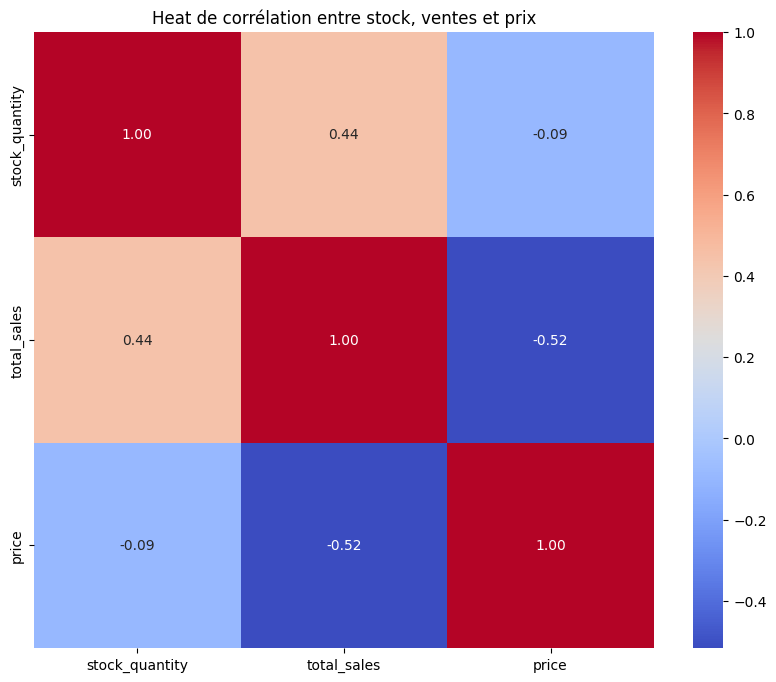

In [136]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn
import seaborn as sns
correlation_matrix = df_merge[['stock_quantity', 'total_sales', 'price']].corr()

#Création d'un heatmap de correlation avec les variables stock, sales et price
#on peut également créer un mask pour n'afficher qu'une demi heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heat de corrélation entre stock, ventes et prix')
plt.show()

In [137]:
#Que peut-on conclure des correlations ?
correlation_matrix
#total_sales (0,43): une augmentation de la quantité de stock est  associée à une augmentation des ventes totales
#price (-0,11): une tendance pour les produits avec un stock plus élevé à avoir un prix légèrement inférieur
#sales/price : une augmentation des ventes totales est généralement associée à une diminution du prix

,stock_quantity,total_sales,price
stock_quantity,1.000000,0.438958,-0.090255
total_sales,0.438958,1.000000,-0.516258
price,-0.090255,-0.516258,1.000000


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [138]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.
df_merge.to_excel('df_merge.xlsx', index=False)

print("DataFrame exported to df_merge.xlsx")
len(df_merge)

DataFrame exported to df_merge.xlsx


825